# Connect to google account

In [1]:
from google.colab import drive
drive.mount('/content/data')

Mounted at /content/data


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Global Variables

In [ ]:
import os
import numpy as np
import pandas as pd
import random
import torch


def reset_seeds(seed=42):
  random.seed(seed)
  os.environ['PYTHONHASHSEED'] = str(seed)    # 파이썬 환경변수 시드 고정
  np.random.seed(seed)
  torch.manual_seed(seed) # cpu 연산 무작위 고정
  torch.cuda.manual_seed(seed) # gpu 연산 무작위 고정
  torch.backends.cudnn.deterministic = True  # cuda 라이브러리에서 Deterministic(결정론적)으로 예측하기 (예측에 대한 불확실성 제거 )


# Load Netflix Data

In [2]:
reset_seeds() # 랜덤고정

import easydict
args = easydict.EasyDict()
from sklearn.model_selection import train_test_split


# 1. 경로 및 파일 설정 (Args 클래스)
class Args:
    def __init__(self):
        self.default_path = 'C:/dev/project/SKN27-2nd-2TEAM/models/data/'

        # 넷플릭스 원본 데이터
        self.users_csv = self.default_path + 'users.csv'
        self.watch_csv = self.default_path + 'watch_history.csv'
        self.movies_csv = self.default_path + 'movies.csv'
        self.rec_logs_csv = self.default_path + 'recommendation_logs.csv'
        self.search_logs_csv = self.default_path + 'search_logs.csv'
        self.reviews_csv = self.default_path + 'reviews.csv'

        # 생성할 파일 경로
        self.train_csv = self.default_path + 'Netflix_train.csv'
        self.test_csv = self.default_path + 'Netflix_test.csv'
        self.submission_filename = 'Netflix_submission.csv'
        self.default_submission_csv = self.default_path + self.submission_filename
        self.save_results = self.default_path + 'Netflix_results.json'

args = Args()

# 2. 메인 데이터 로드 (Target인 churned가 포함된 users.csv)
user = pd.read_csv(args.users_csv).drop_duplicates()        # 'churned' 컬럼이 있다고 가정
watch = pd.read_csv(args.watch_csv).drop_duplicates()
movies = pd.read_csv(args.movies_csv).drop_duplicates()
rec_logs = pd.read_csv(args.rec_logs_csv).drop_duplicates()
search_logs = pd.read_csv(args.search_logs_csv).drop_duplicates()
reviews = pd.read_csv(args.reviews_csv).drop_duplicates()
Netflix_users = pd.read_csv(args.users_csv).drop_duplicates()

# 3. Target 변환 (Active -> Churned)
Netflix_users['is_churned'] = 1 - Netflix_users['is_active']
Netflix_users = Netflix_users.drop(columns=['is_active'])

# 데이터 분석을 위한 변수들
args.random_state = 21
args.results = []

                                    comparison  total_users  changed_users  \
0                        core vs core + review        10000           1084   
1           core vs core + recommendation(all)        10000           2813   
2  core vs core + recommendation(clicked only)        10000            588   

   changed_ratio_%  delayed_users  delayed_ratio_%  median_delay_days  \
0            10.84           1084            10.84                 45   
1            28.13           2813            28.13                 43   
2             5.88            588             5.88                 42   

   mean_delay_days  p75_delay_days  p90_delay_days  max_delay_days  
0            61.66              88             139             356  
1            60.83              84             141             486  
2            60.69              89             138             430  
                           column  non_null_count  non_null_ratio_%
0                 last_watch_date           10000 

C:\Users\Playdata\AppData\Local\Temp\ipykernel_37600\296519677.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


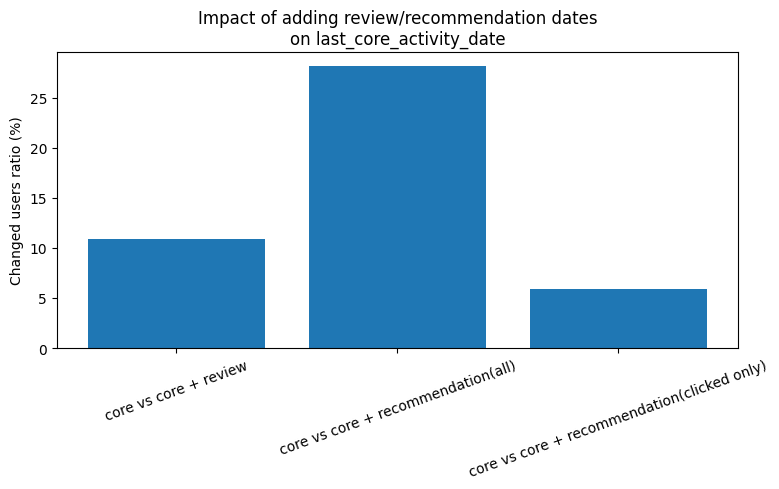

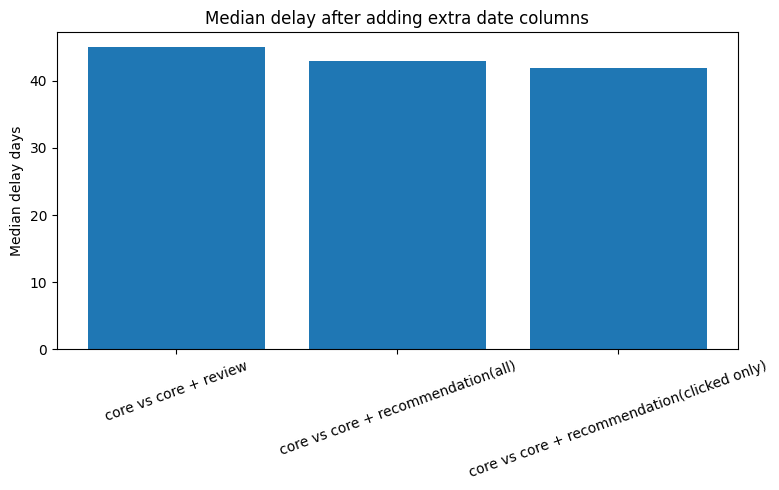

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. 날짜형 변환
# -------------------------------------------------
watch_tmp = watch[['user_id', 'watch_date']].copy()
search_tmp = search_logs[['user_id', 'search_date']].copy()
review_tmp = reviews[['user_id', 'review_date']].copy()
rec_tmp = rec_logs[['user_id', 'recommendation_date', 'was_clicked']].copy()

watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')
search_tmp['search_date'] = pd.to_datetime(search_tmp['search_date'], errors='coerce')
review_tmp['review_date'] = pd.to_datetime(review_tmp['review_date'], errors='coerce')
rec_tmp['recommendation_date'] = pd.to_datetime(rec_tmp['recommendation_date'], errors='coerce')

# recommendation 클릭 여부 0/1 변환
rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})
rec_tmp['was_clicked_num'] = pd.to_numeric(rec_tmp['was_clicked_num'], errors='coerce')


# -------------------------------------------------
# 1. user별 마지막 날짜 map 만들기
# -------------------------------------------------
last_watch_date_map = watch_tmp.groupby('user_id')['watch_date'].max().to_dict()
last_search_date_map = search_tmp.groupby('user_id')['search_date'].max().to_dict()
last_review_date_map = review_tmp.groupby('user_id')['review_date'].max().to_dict()
last_recommendation_date_map = rec_tmp.groupby('user_id')['recommendation_date'].max().to_dict()

# 클릭한 recommendation만 따로
rec_clicked_tmp = rec_tmp[rec_tmp['was_clicked_num'] == 1].copy()
last_recommendation_click_date_map = (
    rec_clicked_tmp.groupby('user_id')['recommendation_date'].max().to_dict()
)


# -------------------------------------------------
# 2. 비교용 user-level 데이터프레임 만들기
# user는 기본 user 테이블
# -------------------------------------------------
compare_df = user[['user_id']].copy()

compare_df['last_watch_date'] = compare_df['user_id'].map(last_watch_date_map)
compare_df['last_search_date'] = compare_df['user_id'].map(last_search_date_map)
compare_df['last_review_date'] = compare_df['user_id'].map(last_review_date_map)
compare_df['last_recommendation_date'] = compare_df['user_id'].map(last_recommendation_date_map)
compare_df['last_recommendation_click_date'] = compare_df['user_id'].map(last_recommendation_click_date_map)

date_cols = [
    'last_watch_date',
    'last_search_date',
    'last_review_date',
    'last_recommendation_date',
    'last_recommendation_click_date'
]

for col in date_cols:
    compare_df[col] = pd.to_datetime(compare_df[col], errors='coerce')


# -------------------------------------------------
# 3. 핵심 기준 날짜 만들기
# "사실상 콘텐츠 소비가 끊긴 날"의 core 기준
# = watch + search
# -------------------------------------------------
compare_df['last_core_activity_date'] = compare_df[['last_watch_date', 'last_search_date']].max(axis=1)

# review 포함
compare_df['last_core_plus_review_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_review_date']
].max(axis=1)

# recommendation 전체 포함
compare_df['last_core_plus_recommendation_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_recommendation_date']
].max(axis=1)

# recommendation 클릭만 포함
compare_df['last_core_plus_recommendation_click_date'] = compare_df[
    ['last_watch_date', 'last_search_date', 'last_recommendation_click_date']
].max(axis=1)


# -------------------------------------------------
# 4. 영향도 비교 함수
# -------------------------------------------------
def summarize_impact(df, base_col, compare_col, label):
    delta_days = (df[compare_col] - df[base_col]).dt.days

    changed_mask = delta_days.notna() & (delta_days != 0)
    delayed_mask = delta_days > 0

    result = {
        'comparison': label,
        'total_users': len(df),
        'changed_users': int(changed_mask.sum()),
        'changed_ratio_%': round(changed_mask.mean() * 100, 2),
        'delayed_users': int(delayed_mask.sum()),
        'delayed_ratio_%': round(delayed_mask.mean() * 100, 2),
        'median_delay_days': int(delta_days[delayed_mask].median()) if delayed_mask.sum() > 0 else 0,
        'mean_delay_days': round(delta_days[delayed_mask].mean(), 2) if delayed_mask.sum() > 0 else 0,
        'p75_delay_days': int(delta_days[delayed_mask].quantile(0.75)) if delayed_mask.sum() > 0 else 0,
        'p90_delay_days': int(delta_days[delayed_mask].quantile(0.90)) if delayed_mask.sum() > 0 else 0,
        'max_delay_days': int(delta_days[delayed_mask].max()) if delayed_mask.sum() > 0 else 0,
    }
    return result


# -------------------------------------------------
# 5. review / recommendation 영향도 요약
# -------------------------------------------------
summary_list = []

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_review_date',
        'core vs core + review'
    )
)

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_recommendation_date',
        'core vs core + recommendation(all)'
    )
)

summary_list.append(
    summarize_impact(
        compare_df,
        'last_core_activity_date',
        'last_core_plus_recommendation_click_date',
        'core vs core + recommendation(clicked only)'
    )
)

summary_df = pd.DataFrame(summary_list)
print(summary_df)


# -------------------------------------------------
# 6. 커버리지 확인
# 각 날짜 컬럼이 실제로 얼마나 있는지
# -------------------------------------------------
coverage_df = pd.DataFrame({
    'column': [
        'last_watch_date',
        'last_search_date',
        'last_review_date',
        'last_recommendation_date',
        'last_recommendation_click_date',
        'last_core_activity_date'
    ],
    'non_null_count': [
        compare_df['last_watch_date'].notna().sum(),
        compare_df['last_search_date'].notna().sum(),
        compare_df['last_review_date'].notna().sum(),
        compare_df['last_recommendation_date'].notna().sum(),
        compare_df['last_recommendation_click_date'].notna().sum(),
        compare_df['last_core_activity_date'].notna().sum(),
    ]
})

coverage_df['non_null_ratio_%'] = round(coverage_df['non_null_count'] / len(compare_df) * 100, 2)
print(coverage_df)


# -------------------------------------------------
# 7. 발표용 그래프 1: 마지막 활동일이 바뀌는 유저 비율
# -------------------------------------------------
plot_df = summary_df.copy()

plt.figure(figsize=(8, 5))
plt.bar(plot_df['comparison'], plot_df['changed_ratio_%'])
plt.ylabel('Changed users ratio (%)')
plt.title('Impact of adding review/recommendation dates\non last_core_activity_date')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 8. 발표용 그래프 2: 바뀐 유저들 기준 지연 일수 중앙값
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.bar(plot_df['comparison'], plot_df['median_delay_days'])
plt.ylabel('Median delay days')
plt.title('Median delay after adding extra date columns')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


=== Non-churn users return gap summary ===
count: 97012
mean: 53.91
median: 38.00
p75: 75.00
p90: 124.00
p95: 161.00
p99: 245.00
max: 537

=== Gap summary table ===
   metric     value
0   count  97012.00
1    mean     53.91
2  median     38.00
3     p75     75.00
4     p90    124.00
5     p95    161.00
6     p99    245.00
7     max    537.00


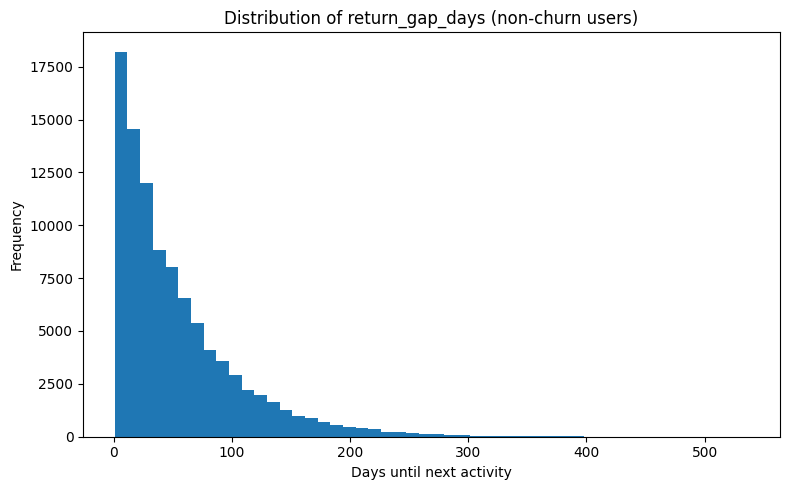

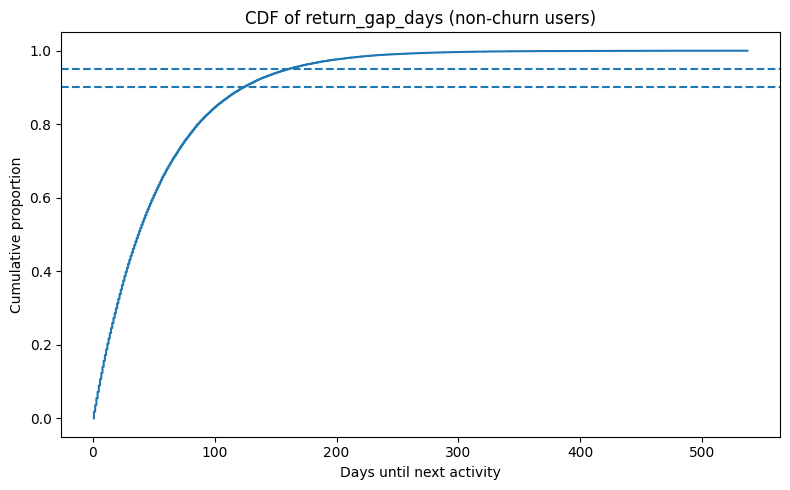

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# 0. non-churn 유저 정의
# -------------------------------------------------
non_churn_user_ids = user.loc[user['is_active'] == True, 'user_id'].unique()

# -------------------------------------------------
# 1. activity 로그 만들기
# 기준: watch_date + search_date
# 같은 날 여러 활동은 1일 1활동으로 처리
# -------------------------------------------------
watch_activity = watch[['user_id', 'watch_date']].copy()
watch_activity = watch_activity.rename(columns={'watch_date': 'activity_date'})
watch_activity['activity_date'] = pd.to_datetime(watch_activity['activity_date'], errors='coerce')

search_activity = search_logs[['user_id', 'search_date']].copy()
search_activity = search_activity.rename(columns={'search_date': 'activity_date'})
search_activity['activity_date'] = pd.to_datetime(search_activity['activity_date'], errors='coerce')

activity_log = pd.concat([watch_activity, search_activity], ignore_index=True)

# non-churn 유저만 남기기
activity_log = activity_log[activity_log['user_id'].isin(non_churn_user_ids)].copy()

# 날짜 없는 행 제거
activity_log = activity_log.dropna(subset=['activity_date'])

# 날짜만 남기기 (시간 제거)
activity_log['activity_date'] = activity_log['activity_date'].dt.normalize()

# 같은 유저가 같은 날 여러 번 활동한 경우 1번으로 처리
activity_log = activity_log.drop_duplicates(subset=['user_id', 'activity_date'])

# -------------------------------------------------
# 2. 유저별 활동일 정렬 후 다음 활동일까지 gap 계산
# -------------------------------------------------
activity_log = activity_log.sort_values(['user_id', 'activity_date']).copy()

activity_log['next_activity_date'] = activity_log.groupby('user_id')['activity_date'].shift(-1)

activity_log['return_gap_days'] = (
    activity_log['next_activity_date'] - activity_log['activity_date']
).dt.days

# 마지막 활동은 다음 활동이 없으므로 제외
gap_df = activity_log.dropna(subset=['return_gap_days']).copy()

# 혹시 이상치/음수 방지
gap_df = gap_df[gap_df['return_gap_days'] >= 0].copy()

# 정수형
gap_df['return_gap_days'] = gap_df['return_gap_days'].astype(int)

# -------------------------------------------------
# 3. 요약 통계
# -------------------------------------------------
gap_summary = {
    'count': len(gap_df),
    'mean': gap_df['return_gap_days'].mean(),
    'median': gap_df['return_gap_days'].median(),
    'p75': gap_df['return_gap_days'].quantile(0.75),
    'p90': gap_df['return_gap_days'].quantile(0.90),
    'p95': gap_df['return_gap_days'].quantile(0.95),
    'p99': gap_df['return_gap_days'].quantile(0.99),
    'max': gap_df['return_gap_days'].max()
}

print("=== Non-churn users return gap summary ===")
for k, v in gap_summary.items():
    print(f"{k}: {v:.2f}" if isinstance(v, float) else f"{k}: {v}")

# -------------------------------------------------
# 4. 발표용 표
# -------------------------------------------------
gap_summary_df = pd.DataFrame({
    'metric': ['count', 'mean', 'median', 'p75', 'p90', 'p95', 'p99', 'max'],
    'value': [
        len(gap_df),
        round(gap_df['return_gap_days'].mean(), 2),
        round(gap_df['return_gap_days'].median(), 2),
        round(gap_df['return_gap_days'].quantile(0.75), 2),
        round(gap_df['return_gap_days'].quantile(0.90), 2),
        round(gap_df['return_gap_days'].quantile(0.95), 2),
        round(gap_df['return_gap_days'].quantile(0.99), 2),
        gap_df['return_gap_days'].max()
    ]
})

print("\n=== Gap summary table ===")
print(gap_summary_df)

# -------------------------------------------------
# 5. 히스토그램
# -------------------------------------------------
plt.figure(figsize=(8, 5))
plt.hist(gap_df['return_gap_days'], bins=50)
plt.title('Distribution of return_gap_days (non-churn users)')
plt.xlabel('Days until next activity')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 6. 누적분포(CDF) 그래프
# 발표용으로 threshold 설명할 때 좋음
# -------------------------------------------------
sorted_gaps = np.sort(gap_df['return_gap_days'].values)
cdf = np.arange(1, len(sorted_gaps) + 1) / len(sorted_gaps)

plt.figure(figsize=(8, 5))
plt.plot(sorted_gaps, cdf)
plt.axhline(0.90, linestyle='--')
plt.axhline(0.95, linestyle='--')
plt.title('CDF of return_gap_days (non-churn users)')
plt.xlabel('Days until next activity')
plt.ylabel('Cumulative proportion')
plt.tight_layout()
plt.show()

In [5]:
from something import NetflixFeatureBuilder

builder = NetflixFeatureBuilder(
    user=user,
    watch=watch,
    reviews=reviews,
    rec_logs=rec_logs,
    search_logs=search_logs,
    movies=movies
)

print(hasattr(builder, 'new_user'))  # True 나와야 정상

True


In [6]:
builder.add_last_activity_date()
new_user = builder.get_data()
new_user.head()

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:362: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,monthly_spend,primary_device,household_size,created_at,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29


In [7]:
builder.add_estimated_churn_date_p50()
builder.add_final_estimated_churn_date()

new_user = builder.get_data()
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,created_at,last_watch_date,last_search_date,last_review_date,last_recommendation_click_date,last_activity_date,last_core_activity_date,estimated_churn_date_p50,is_p50_estimate_valid,final_estimated_churn_date
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2023-04-01 14:40:50.540242,2025-10-30,2024-12-29,2024-01-09,NaT,2025-10-30,2025-10-30,2025-12-07,True,NaT
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2024-10-10 15:39:11.030515,2025-11-28,2025-12-08,2025-09-12,NaT,2025-12-08,2025-12-08,2026-01-15,True,NaT
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2024-06-29 14:27:49.560875,2025-06-24,NaT,2024-04-17,2025-04-13,2025-06-24,2025-06-24,2025-08-01,True,2025-08-01
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2023-04-11 01:01:59.614841,2025-12-29,2025-12-29,2025-03-12,NaT,2025-12-29,2025-12-29,2026-02-05,True,NaT
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-04-12 19:59:30.137806,2025-09-19,2025-09-29,2025-09-26,NaT,2025-09-29,2025-09-29,2025-11-06,True,NaT


In [11]:
OBS_END_DATE = pd.to_datetime('2025-12-31')

new_user['final_estimated_churn_date'] = pd.to_datetime(
    new_user['final_estimated_churn_date'],
    errors='coerce'
)

new_user.loc[
    new_user['final_estimated_churn_date'] > OBS_END_DATE,
    'final_estimated_churn_date'
] = OBS_END_DATE

# 보기 좋게 date만 남기기
new_user['final_estimated_churn_date'] = new_user['final_estimated_churn_date'].dt.date

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_estimated_churn_trend(df, date_col='final_estimated_churn_date', x_unit='month'):
    """
    estimated churn date 기준으로 이탈 추세 그래프를 그리는 함수

    Parameters
    ----------
    df : pd.DataFrame
        new_user 데이터프레임
    date_col : str
        이탈 추정일 컬럼명
    x_unit : str
        'day' 또는 'month'
    """

    plot_df = df.copy()

    # 날짜형 변환
    plot_df[date_col] = pd.to_datetime(plot_df[date_col], errors='coerce')

    # 빈칸(active 유저)은 제외
    plot_df = plot_df.dropna(subset=[date_col]).copy()

    # x축 단위 선택
    if x_unit == 'day':
        plot_df['x_date'] = plot_df[date_col].dt.date
        xlabel = 'Estimated churn date (day)'
    elif x_unit == 'month':
        plot_df['x_date'] = plot_df[date_col].dt.to_period('M').astype(str)
        xlabel = 'Estimated churn date (month)'
    else:
        raise ValueError("x_unit은 'day' 또는 'month'만 가능합니다.")

    # user count 집계
    count_df = (
        plot_df.groupby('x_date')['user_id']
        .count()
        .reset_index(name='user_count')
    )

    # 그래프
    plt.figure(figsize=(12, 6))
    plt.bar(count_df['x_date'].astype(str), count_df['user_count'])
    plt.xlabel(xlabel)
    plt.ylabel('User count')
    plt.title(f'Estimated churn users by {x_unit}')
    
    if x_unit == 'day':
        plt.xticks(rotation=90)
    else:
        plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    return count_df

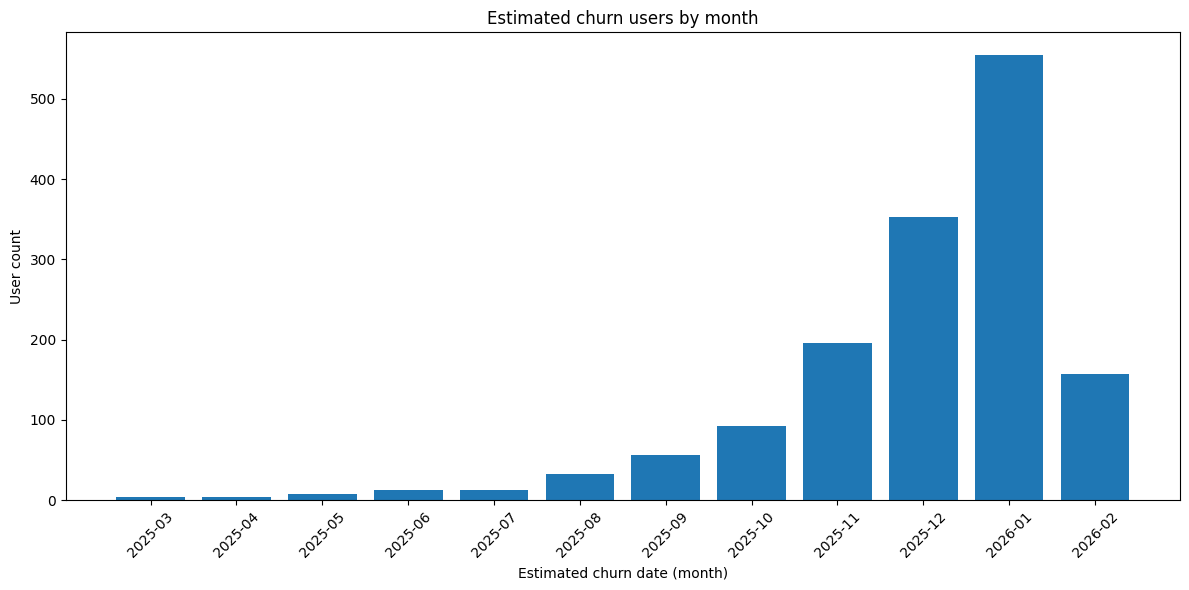

,x_date,user_count
0,2025-03,4
1,2025-04,4
2,2025-05,7
3,2025-06,12
4,2025-07,12


In [9]:
monthly_churn = plot_estimated_churn_trend(
    new_user,
    date_col='final_estimated_churn_date',
    x_unit='month'
)
monthly_churn.head()

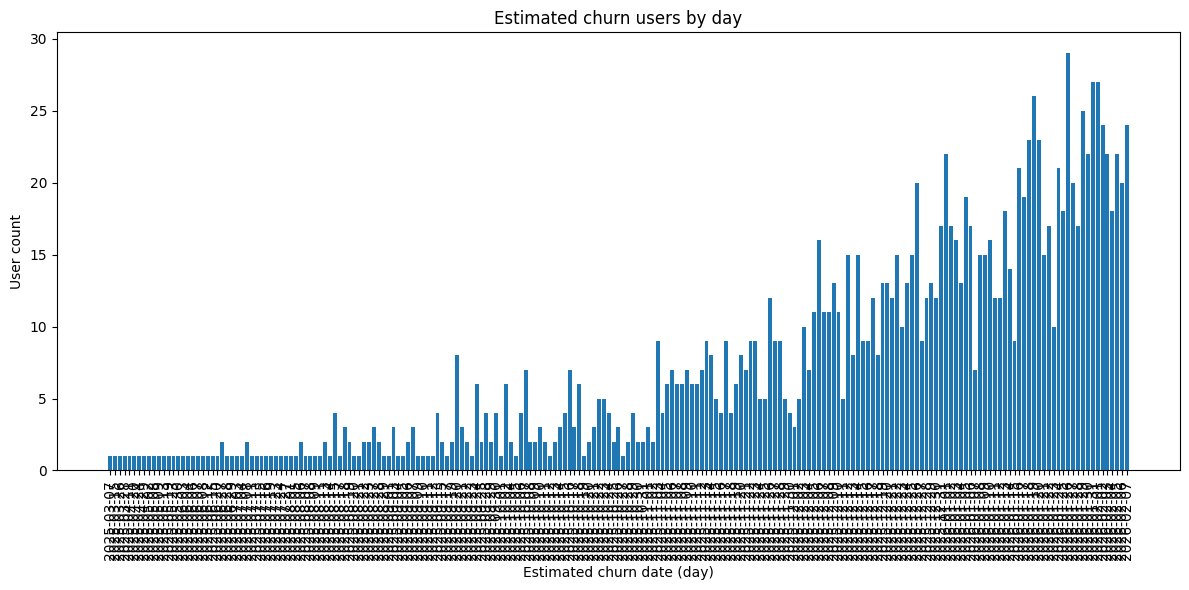

,x_date,user_count
0,2025-03-07,1
1,2025-03-15,1
2,2025-03-26,1
3,2025-03-28,1
4,2025-04-11,1


In [10]:
daily_churn = plot_estimated_churn_trend(
    new_user,
    date_col='final_estimated_churn_date',
    x_unit='day'
)
daily_churn.head()

In [9]:
import os

save_path = r'C:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\new_user.csv'

new_user = builder.get_data()
new_user.to_csv(save_path, index=False, encoding='utf-8-sig')

print(f"저장 완료: {save_path}")

저장 완료: C:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\new_user.csv


In [5]:
builder.add_recommendation_click_rate()
builder.add_content_interactions()
builder.add_rating_given()
builder.add_completion_rate()
builder.add_watch_sessions_per_week()
builder.add_avg_watch_time_minutes()
builder.add_favorite_genre()
builder.add_last_activity_date()

new_user = builder.get_data()
new_user.head()

c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:77: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
c:\dev\project\SKN27-2nd-2TEAM\models\Netflix_ML\JAEKANG\something.py:346: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future ve

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,created_at,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre,last_activity_date,days_since_last_activity
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2023-04-01 14:40:50.540242,0,2,4,53,1,54,War,2025-10-30,62
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2024-10-10 15:39:11.030515,0,4,4,33,1,51,Horror,2025-12-08,23
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2024-06-29 14:27:49.560875,33,3,4,44,1,83,Animation,2025-06-24,190
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2023-04-11 01:01:59.614841,0,4,2,26,1,82,Drama,2025-12-29,2
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-04-12 19:59:30.137806,0,5,3,20,1,53,Drama,2025-09-29,93


In [35]:
# -------------------------------------------------
# recommendation_click_rate 만들기
# 기준 테이블: user
# 원본 로그: rec_logs
# 중복 제거 없이, recommendation 로그 전체 행 기준으로 계산
# 결과는 % 형태 정수값 (예: 0.3333 -> 33)
# -------------------------------------------------

# 1. recommendation 로그에서 필요한 컬럼만 가져오기
rec_tmp = rec_logs[['user_id', 'recommendation_id', 'was_clicked']].copy()

# 2. 클릭 여부를 0/1로 변환
rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})

# 3. 숫자형으로 변환
rec_tmp['was_clicked_num'] = pd.to_numeric(rec_tmp['was_clicked_num'], errors='coerce')

# 4. user별 recommendation_click_rate 계산
df_rec_click_rate = (
    rec_tmp
    .groupby('user_id', as_index=False)
    .agg(recommendation_click_rate=('was_clicked_num', 'mean'))
)

# 5. 100 곱하고 소수점 제거
df_rec_click_rate['recommendation_click_rate'] = (
    df_rec_click_rate['recommendation_click_rate'] * 100
).astype(int)

# 6. user는 그대로 두고, 새로운 변수 생성
new_user = user.copy()

# 7. user_id 기준으로 recommendation_click_rate를 맨 오른쪽 컬럼에 추가
rec_click_rate_map = df_rec_click_rate.set_index('user_id')['recommendation_click_rate']

new_user['recommendation_click_rate'] = (
    new_user['user_id']
    .map(rec_click_rate_map)
    .fillna(0)
    .astype(int)
)

# 8. 확인
new_user.head()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_32228\1014698582.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at,recommendation_click_rate
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,2024-04-08,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,0
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,2024-05-24,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,0
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,2023-09-22,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,33
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,2024-08-21,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,0
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,2024-10-28,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,0


In [36]:
# -------------------------------------------------
# content_interactions 만들기
# 정의:
# user별 (리뷰 작성 수 + 추천 클릭 수 + 검색 결과 클릭 수)
# -------------------------------------------------

# 1. reviews.csv -> user별 리뷰 작성 수
review_count = (
    reviews.groupby('user_id')['review_id']
    .count()
    .to_dict()
)

# 2. recommendation_logs.csv -> user별 추천 클릭 수
rec_tmp = rec_logs[['user_id', 'was_clicked']].copy()

rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})

rec_tmp['was_clicked_num'] = pd.to_numeric(rec_tmp['was_clicked_num'], errors='coerce')

rec_click_count = (
    rec_tmp.groupby('user_id')['was_clicked_num']
    .sum()
    .to_dict()
)

# 3. search_logs.csv -> user별 검색 결과 클릭 수
# clicked_result_position 값이 있으면 검색 결과를 클릭한 것으로 간주
search_tmp = search_logs[['user_id', 'clicked_result_position']].copy()

search_tmp['search_clicked'] = search_tmp['clicked_result_position'].notna().astype(int)

search_click_count = (
    search_tmp.groupby('user_id')['search_clicked']
    .sum()
    .to_dict()
)

# 4. 기존 new_user에 content_interactions 컬럼 추가
#    (new_user가 이미 recommendation_click_rate 등을 포함한 상태라고 가정)
new_user = new_user.copy()

new_user['content_interactions'] = (
    new_user['user_id'].map(review_count).fillna(0)
    + new_user['user_id'].map(rec_click_count).fillna(0)
    + new_user['user_id'].map(search_click_count).fillna(0)
).astype(int)

# 5. 확인
new_user.head()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_32228\1850849017.py:17: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at,recommendation_click_rate,content_interactions
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,2024-04-08,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,0,2
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,2024-05-24,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,0,4
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,2023-09-22,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,33,3
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,2024-08-21,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,0,4
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,2024-10-28,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,0,5


In [37]:
# -------------------------------------------------
# rating_given 만들기
# 정의:
# user별 리뷰 평점 평균 -> 반올림 -> int 변환
# -------------------------------------------------

# 1. reviews에서 user별 평균 평점 계산
rating_map = (
    reviews.groupby('user_id')['rating']
    .mean()          # user별 평균 평점
    .round(0)        # 반올림
    .astype(int)     # 정수형 변환
    .to_dict()
)

# 2. 기존 new_user에 rating_given 컬럼 추가
new_user = new_user.copy()

new_user['rating_given'] = (
    new_user['user_id']
    .map(rating_map)
    .fillna(0)
    .astype(int)
)

# 3. 확인
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at,recommendation_click_rate,content_interactions,rating_given
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,2024-04-08,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,0,2,4
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,2024-05-24,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,0,4,4
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,2023-09-22,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,33,3,4
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,2024-08-21,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,0,4,2
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,2024-10-28,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,0,5,3


In [38]:
# -------------------------------------------------
# completion_rate 만들기
# 정의:
# user별 완료 시청 비율
# = 완료한 시청 수 / 전체 시청 수
# 결과는 100 곱하고 소수점 아래 버린 int 값
# -------------------------------------------------

# 1. 필요한 컬럼만 복사
watch_tmp = watch[['user_id', 'progress_percentage', 'action']].copy()

# 2. progress_percentage 숫자형 변환
watch_tmp['progress_percentage'] = pd.to_numeric(
    watch_tmp['progress_percentage'],
    errors='coerce'
)

# 3. 완료 여부 컬럼 만들기
watch_tmp['is_completed'] = (
    (watch_tmp['action'].astype(str).str.lower() == 'completed') |
    (watch_tmp['progress_percentage'] >= 100)
).astype(int)

# 4. user별 completion_rate 계산
completion_rate_map = (
    (watch_tmp.groupby('user_id')['is_completed'].mean() * 100)
    .astype(int)   # 소수점 아래 버리기
    .to_dict()
)

# 5. new_user에 completion_rate 컬럼 추가
new_user = new_user.copy()

new_user['completion_rate'] = (
    new_user['user_id']
    .map(completion_rate_map)
    .fillna(0)
    .astype(int)
)

# 6. 확인
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at,recommendation_click_rate,content_interactions,rating_given,completion_rate
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,2024-04-08,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,0,2,4,53
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,2024-05-24,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,0,4,4,33
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,2023-09-22,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,33,3,4,44
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,2024-08-21,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,0,4,2,26
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,2024-10-28,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,0,5,3,20


In [39]:
# -------------------------------------------------
# watch_sessions_per_week 만들기
# 정의:
# user별 주간 세션 수 평균 -> 반올림 -> int 변환
# -------------------------------------------------

# 1. 필요한 컬럼만 복사
watch_tmp = watch[['user_id', 'session_id', 'watch_date']].copy()

# 2. 날짜형 변환
watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')

# 3. 주 단위 컬럼 생성
watch_tmp['watch_week'] = watch_tmp['watch_date'].dt.to_period('W')

# 4. user별 / 주별 세션 수 계산
weekly_session = (
    watch_tmp
    .groupby(['user_id', 'watch_week'])['session_id']
    .nunique()
    .reset_index(name='weekly_session_count')
)

# 5. user별 주간 세션 수 평균 계산 -> 반올림 -> int
watch_sessions_per_week_map = (
    weekly_session
    .groupby('user_id')['weekly_session_count']
    .mean()
    .round(0)
    .astype(int)
    .to_dict()
)

# 6. new_user에 컬럼 추가
new_user = new_user.copy()

new_user['watch_sessions_per_week'] = (
    new_user['user_id']
    .map(watch_sessions_per_week_map)
    .fillna(0)
    .astype(int)
)

# 7. 확인
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,is_active,monthly_spend,primary_device,household_size,created_at,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,0,2,4,53,1
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,0,4,4,33,1
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,33,3,4,44,1
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,0,4,2,26,1
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,0,5,3,20,1


In [40]:
# -------------------------------------------------
# avg_watch_time_minutes 만들기
# 정의:
# user별 하루 평균 시청 시간 -> 반올림 -> int 변환
# -------------------------------------------------

# 1. 필요한 컬럼만 복사
watch_tmp = watch[['user_id', 'watch_date', 'watch_duration_minutes']].copy()

# 2. 날짜형 / 숫자형 변환
watch_tmp['watch_date'] = pd.to_datetime(watch_tmp['watch_date'], errors='coerce')
watch_tmp['watch_duration_minutes'] = pd.to_numeric(
    watch_tmp['watch_duration_minutes'],
    errors='coerce'
)

# 3. user별, 날짜별 총 시청 시간 계산
daily_watch = (
    watch_tmp
    .groupby(['user_id', 'watch_date'])['watch_duration_minutes']
    .sum()
    .reset_index(name='daily_watch_minutes')
)

# 4. user별 하루 평균 시청 시간 계산 -> 반올림 -> int
avg_watch_time_map = (
    daily_watch
    .groupby('user_id')['daily_watch_minutes']
    .mean()
    .round(0)
    .astype(int)
    .to_dict()
)

# 5. new_user에 컬럼 추가
new_user = new_user.copy()

new_user['avg_watch_time_minutes'] = (
    new_user['user_id']
    .map(avg_watch_time_map)
    .fillna(0)
    .astype(int)
)

# 6. 확인
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,monthly_spend,primary_device,household_size,created_at,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,0,2,4,53,1,54
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,0,4,4,33,1,51
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,33,3,4,44,1,83
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,0,4,2,26,1,82
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,0,5,3,20,1,53


In [41]:
# -------------------------------------------------
# favorite_genre 만들기
# 정의:
# user별 가장 많이 본 장르
# -------------------------------------------------

# 1. 필요한 컬럼만 복사
watch_tmp = watch[['user_id', 'movie_id']].copy()
movies_tmp = movies[['movie_id', 'genre_primary']].copy()

# 2. watch와 movies를 movie_id 기준으로 병합
watch_genre = watch_tmp.merge(
    movies_tmp,
    on='movie_id',
    how='left'
)

# 3. user별 가장 많이 본 장르 찾기
favorite_genre_map = (
    watch_genre
    .groupby('user_id')['genre_primary']
    .agg(lambda x: x.dropna().value_counts().idxmax() if not x.dropna().empty else None)
    .to_dict()
)

# 4. new_user에 컬럼 추가
new_user = new_user.copy()

new_user['favorite_genre'] = (
    new_user['user_id']
    .map(favorite_genre_map)
    .fillna('Unknown')
)

# 5. 확인
new_user.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,primary_device,household_size,created_at,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,Laptop,1.0,2023-04-01 14:40:50.540242,0,2,4,53,1,54,War
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,Desktop,2.0,2024-10-10 15:39:11.030515,0,4,4,33,1,51,Horror
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,Desktop,3.0,2024-06-29 14:27:49.560875,33,3,4,44,1,83,Animation
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,Laptop,2.0,2023-04-11 01:01:59.614841,0,4,2,26,1,82,Drama
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,Desktop,6.0,2025-04-12 19:59:30.137806,0,5,3,20,1,53,Drama


In [42]:
# -------------------------------------------------
# last_activity_date / days_since_last_activity 만들기
# 정의:
# last_activity_date
#   = user별 최근 활동 날짜
#   = watch_date, search_date, review_date, clicked recommendation_date 중 최댓값
#
# days_since_last_activity
#   = 기준일 - last_activity_date
#   = 기준일은 전체 활동 로그 중 가장 최근 날짜
# -------------------------------------------------

# 1. watch 활동
watch_activity = watch[['user_id', 'watch_date']].copy()
watch_activity = watch_activity.rename(columns={'watch_date': 'activity_date'})
watch_activity['activity_date'] = pd.to_datetime(watch_activity['activity_date'], errors='coerce')

# 2. search 활동
search_activity = search_logs[['user_id', 'search_date']].copy()
search_activity = search_activity.rename(columns={'search_date': 'activity_date'})
search_activity['activity_date'] = pd.to_datetime(search_activity['activity_date'], errors='coerce')

# 3. review 활동
review_activity = reviews[['user_id', 'review_date']].copy()
review_activity = review_activity.rename(columns={'review_date': 'activity_date'})
review_activity['activity_date'] = pd.to_datetime(review_activity['activity_date'], errors='coerce')

# 4. recommendation 활동 (클릭한 경우만 활동으로 인정)
rec_tmp = rec_logs[['user_id', 'recommendation_date', 'was_clicked']].copy()

rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({
    True: 1, False: 0,
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    1: 1, 0: 0
})

rec_tmp['was_clicked_num'] = pd.to_numeric(rec_tmp['was_clicked_num'], errors='coerce')
rec_tmp['recommendation_date'] = pd.to_datetime(rec_tmp['recommendation_date'], errors='coerce')

rec_activity = rec_tmp.loc[rec_tmp['was_clicked_num'] == 1, ['user_id', 'recommendation_date']].copy()
rec_activity = rec_activity.rename(columns={'recommendation_date': 'activity_date'})

# 5. 모든 활동 로그 합치기
activity_log = pd.concat(
    [watch_activity, search_activity, review_activity, rec_activity],
    axis=0,
    ignore_index=True
)

# 날짜 없는 행 제거
activity_log = activity_log.dropna(subset=['activity_date'])

# 6. user별 마지막 활동일 map 만들기
last_activity_map = (
    activity_log
    .groupby('user_id')['activity_date']
    .max()
    .to_dict()
)

# 7. 기준일 설정
reference_date = activity_log['activity_date'].max()

# 8. new_user에 컬럼 추가
new_user = new_user.copy()

new_user['last_activity_date'] = (
    new_user['user_id']
    .map(last_activity_map)
)

# 날짜 형식 정리
new_user['last_activity_date'] = pd.to_datetime(
    new_user['last_activity_date'],
    errors='coerce'
)

# 9. days_since_last_activity 추가
new_user['days_since_last_activity'] = (
    (reference_date - new_user['last_activity_date']).dt.days
    .fillna(0)
    .astype(int)
)

# 10. last_activity_date는 보기 좋게 날짜만 남기기
new_user['last_activity_date'] = new_user['last_activity_date'].dt.date

# 11. 확인
new_user.head()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_32228\2043177398.py:31: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rec_tmp['was_clicked_num'] = rec_tmp['was_clicked'].replace({


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,...,created_at,recommendation_click_rate,content_interactions,rating_given,completion_rate,watch_sessions_per_week,avg_watch_time_minutes,favorite_genre,last_activity_date,days_since_last_activity
0,user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,...,2023-04-01 14:40:50.540242,0,2,4,53,1,54,War,2025-10-30,62
1,user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,...,2024-10-10 15:39:11.030515,0,4,4,33,1,51,Horror,2025-12-08,23
2,user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,...,2024-06-29 14:27:49.560875,33,3,4,44,1,83,Animation,2025-06-24,190
3,user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,...,2023-04-11 01:01:59.614841,0,4,2,26,1,82,Drama,2025-12-29,2
4,user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,...,2025-04-12 19:59:30.137806,0,5,3,20,1,53,Drama,2025-09-29,93


### column
- user_id: 사용자 ID
- email: 개인정보 (학습 제외)
- first_name, last_name: 이름 (학습 제외)
- age: 사용자의 나이
- gender:	사용자의 성별
- country, state_province, city : 거주지 정보
- household_size: 가구원 수
- subscription_plan: 구독 등급
- subscription_start_date:구독 시작일
- monthly_spend: 월별 지출액
- primary_device: 주 사용 기기
- created_at: 계정 생성 일시

### Target
- is_churned: 이탈률

In [41]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('fivethirtyeight')
plt.ion()

import warnings
warnings.filterwarnings('ignore')

In [42]:
ori_train = pd.read_csv(args.train_csv)
ori_test = pd.read_csv(args.test_csv)

ori_train.shape, ori_test.shape

((8240, 15), (2060, 15))

In [7]:
# 예측할 유저 수, 컬럼의 개수
pd.read_csv(args.default_submission_csv).shape

(2060, 2)

In [8]:
ori_train.columns

Index(['user_id', 'email', 'first_name', 'last_name', 'age', 'gender',
       'country', 'state_province', 'city', 'subscription_plan',
       'subscription_start_date', 'monthly_spend', 'primary_device',
       'household_size', 'created_at'],
      dtype='object')

In [9]:
Netflix.head()

,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,monthly_spend,primary_device,household_size,created_at
0,user_01408,lgonzales@example.net,Elizabeth,Gutierrez,12.0,Female,USA,Michigan,Lake Manueltown,Premium+,2025-06-29,41.40,Tablet,1.0,2023-09-17 21:10:22.351888
1,user_06694,jasonnewman@example.net,Jeremy,Soto,37.0,Female,Canada,Manitoba,North Ronald,Basic,2025-04-02,7.06,Laptop,2.0,2025-02-20 09:15:30.095752
2,user_06874,robert38@example.net,Erin,Franklin,39.0,Other,USA,North Carolina,South Stephanie,Premium,2023-05-22,5.11,Tablet,3.0,2024-09-29 15:46:09.844169
3,user_06611,brenda86@example.com,Scott,Montgomery,71.0,Female,USA,Virginia,Gonzalezfort,Premium,2022-12-26,16.79,Smart TV,NaN,2023-01-18 22:58:54.815694
4,user_06673,lauraprice@example.org,William,Sparks,12.0,Female,USA,Washington,Phamton,Basic,2022-12-17,13.21,Mobile,1.0,2023-03-04 19:59:17.545706


In [10]:
# 주요 통계치(평균, 최솟값, 최댓)
display(Netflix.describe())

,age,monthly_spend,household_size
count,7233.000000,7435.000000,7003.000000
mean,34.968616,22.690048,2.857204
std,12.538932,69.117998,1.560418
min,-7.000000,0.110000,1.000000
25%,27.000000,7.845000,2.000000
50%,35.000000,13.600000,2.000000
75%,43.000000,21.675000,4.000000
max,109.000000,997.800000,8.000000


# train_test_split

In [11]:
# 1. 먼저 X(피처)와 y(타겟)를 분리
X = Netflix_users.drop(columns=['is_churned']) # 정답 컬럼 제외
y = Netflix_users['is_churned']              # 정답 컬럼만 선택

# 2. 그 다음 split을 진행합니다.
X_tr, X_te, y_tr, y_te = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # 분류 문제라면 타겟 데이터(y)를 기준으로 층화 추출
)

# 결과 확인
X_tr.shape, X_te.shape, y_tr.shape, y_te.shape

((8240, 15), (2060, 15), (8240,), (2060,))

# Netflix Base Model

In [12]:
train = X_tr.copy()
test = X_te.copy()
ori_te = ori_test.copy()

train.shape, test.shape, ori_te.shape

((8240, 15), (2060, 15), (2060, 15))

In [13]:
Netflix.columns

Index(['user_id', 'email', 'first_name', 'last_name', 'age', 'gender',
       'country', 'state_province', 'city', 'subscription_plan',
       'subscription_start_date', 'monthly_spend', 'primary_device',
       'household_size', 'created_at'],
      dtype='object')

## Data Preprocessing

In [14]:
# 데이터 크기 및 상위 행 확인
print(f"데이터셋 모양: {Netflix.shape}")
display(Netflix.head())

# 컬럼 정보 및 결측치 확인
Netflix.info()

데이터셋 모양: (8240, 15)


,user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,monthly_spend,primary_device,household_size,created_at
0,user_01408,lgonzales@example.net,Elizabeth,Gutierrez,12.0,Female,USA,Michigan,Lake Manueltown,Premium+,2025-06-29,41.40,Tablet,1.0,2023-09-17 21:10:22.351888
1,user_06694,jasonnewman@example.net,Jeremy,Soto,37.0,Female,Canada,Manitoba,North Ronald,Basic,2025-04-02,7.06,Laptop,2.0,2025-02-20 09:15:30.095752
2,user_06874,robert38@example.net,Erin,Franklin,39.0,Other,USA,North Carolina,South Stephanie,Premium,2023-05-22,5.11,Tablet,3.0,2024-09-29 15:46:09.844169
3,user_06611,brenda86@example.com,Scott,Montgomery,71.0,Female,USA,Virginia,Gonzalezfort,Premium,2022-12-26,16.79,Smart TV,NaN,2023-01-18 22:58:54.815694
4,user_06673,lauraprice@example.org,William,Sparks,12.0,Female,USA,Washington,Phamton,Basic,2022-12-17,13.21,Mobile,1.0,2023-03-04 19:59:17.545706


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8240 entries, 0 to 8239
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  8240 non-null   object 
 1   email                    8240 non-null   object 
 2   first_name               8240 non-null   object 
 3   last_name                8240 non-null   object 
 4   age                      7233 non-null   float64
 5   gender                   7603 non-null   object 
 6   country                  8240 non-null   object 
 7   state_province           8240 non-null   object 
 8   city                     8240 non-null   object 
 9   subscription_plan        8240 non-null   object 
 10  subscription_start_date  8240 non-null   object 
 11  monthly_spend            7435 non-null   float64
 12  primary_device           8240 non-null   object 
 13  household_size           7003 non-null   float64
 14  created_at              

### Drop columns

In [15]:
# 1. 제거하기 전, 제출용 user_id 따로 저장 (매우 중요!)
test_user_id = test['user_id'].copy()

print(f'before: {train.shape} / {test.shape}')

# 2. 불필요한 컬럼 정의 및 제거
drop_cols = ['user_id', 'email', 'first_name', 'last_name', 'created_at', 'country', 'state_province', 'city' ]

# 실제 데이터프레임에서 제거 (inplace=True로 바로 반영)
train.drop(drop_cols, axis=1, inplace=True)
test.drop(drop_cols, axis=1, inplace=True)
ori_te.drop(drop_cols, axis=1, inplace=True)

print(f'after: {train.shape} / {test.shape}')

train.info()

before: (8240, 15) / (2060, 15)
after: (8240, 7) / (2060, 7)
<class 'pandas.core.frame.DataFrame'>
Index: 8240 entries, 1407 to 131
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7233 non-null   float64
 1   gender                   7603 non-null   object 
 2   subscription_plan        8240 non-null   object 
 3   subscription_start_date  8240 non-null   object 
 4   monthly_spend            7435 non-null   float64
 5   primary_device           8240 non-null   object 
 6   household_size           7003 non-null   float64
dtypes: float64(3), object(4)
memory usage: 515.0+ KB


### Missing values

In [16]:
train.isnull().sum()

,0
age,1007
gender,637
subscription_plan,0
subscription_start_date,0
monthly_spend,805
primary_device,0
household_size,1237


In [17]:
test.isnull().sum()

,0
age,222
gender,187
subscription_plan,0
subscription_start_date,0
monthly_spend,212
primary_device,0
household_size,308


In [18]:
ori_te.isnull().sum()

,0
age,222
gender,187
subscription_plan,0
subscription_start_date,0
monthly_spend,212
primary_device,0
household_size,308


In [19]:
# 1. 연령대(Age Group) 생성을 위한 함수
def get_age_group(age):
    if pd.isna(age): return 'Unknown'
    if age < 20: return '10s'
    elif age < 40: return '20-30s'
    elif age < 60: return '40-50s'
    else: return '60s+'

# 2. age(나이)와 gender(성별) 먼저 처리 (Unknown 방지)
age_median = train['age'].median()
gender_mode = train['gender'].mode()[0]

for df in [train, test, ori_te]:
    df['age'] = df['age'].fillna(age_median)
    df['gender'] = df['gender'].fillna(gender_mode)

# 3. 모든 데이터셋에 연령대 컬럼 임시 생성 (age 결측치 처리 후)
for df in [train, test, ori_te]:
    df['age_group'] = df['age'].apply(get_age_group)

# 4. [가설] 10대 지출액 결측치를 0으로 우선 채우기
for df in [train, test, ori_te]:
    df.loc[(df['age_group'] == '10s') & (df['monthly_spend'].isna()), 'monthly_spend'] = 0

# 5. 수치형 컬럼들(monthly_spend, household_size) 처리
fill_cols = ['monthly_spend', 'household_size']

for col in fill_cols:
    # 기준은 항상 train 데이터의 중앙값
    medians = train.groupby('age_group')[col].median()
    overall_median = train[col].median()  # Unknown 등 매핑 실패 대비 전체 중앙값

    for df in [train, test, ori_te]:
        df[col] = df[col].fillna(df['age_group'].map(medians))
        df[col] = df[col].fillna(overall_median)  # 매핑 실패한 결측치 처리

# 6. 사용이 끝난 임시 컬럼 삭제 및 불필요한 컬럼 제거
drop_cols = ['age_group']

for df in [train, test, ori_te]:
    actual_drop = [c for c in drop_cols if c in df.columns]
    df.drop(columns=actual_drop, inplace=True)

train.isnull().sum().sum(), test.isnull().sum().sum(), ori_te.isnull().sum().sum()

(np.int64(0), np.int64(0), np.int64(0))

### Outlier Handling

In [20]:
# 수치형 컬럼 자동 선택
num_cols = train.select_dtypes(include=['number']).columns

print("=" * 55)
print("        IQR 기반 이상치 탐지 결과 (train 기준)")
print("=" * 55)

outlier_summary = []

for col in num_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_mask = (train[col] < lower) | (train[col] > upper)
    outlier_count = outlier_mask.sum()
    outlier_ratio = outlier_count / len(train) * 100

    outlier_summary.append({
        'column': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'lower_bound': round(lower, 2),
        'upper_bound': round(upper, 2),
        'outlier_count': outlier_count,
        'outlier_ratio': f'{outlier_ratio:.2f}%'
    })

    print(f"\n [{col}]")
    print(f"   정상 범위 : {round(lower, 2)} ~ {round(upper, 2)}")
    print(f"   이상치 수 : {outlier_count}개 ({outlier_ratio:.2f}%)")

print("\n" + "=" * 55)

# 요약 데이터프레임
df_outlier_summary = pd.DataFrame(outlier_summary)
df_outlier_summary

        IQR 기반 이상치 탐지 결과 (train 기준)

 [age]
   정상 범위 : 7.0 ~ 63.0
   이상치 수 : 139개 (1.69%)

 [monthly_spend]
   정상 범위 : -10.06 ~ 38.75
   이상치 수 : 394개 (4.78%)

 [household_size]
   정상 범위 : -1.0 ~ 7.0
   이상치 수 : 53개 (0.64%)



,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_ratio
0,age,28.00,42.00,14.0,7.00,63.00,139,1.69%
1,monthly_spend,8.24,20.44,12.2,-10.06,38.75,394,4.78%
2,household_size,2.00,4.00,2.0,-1.00,7.00,53,0.64%


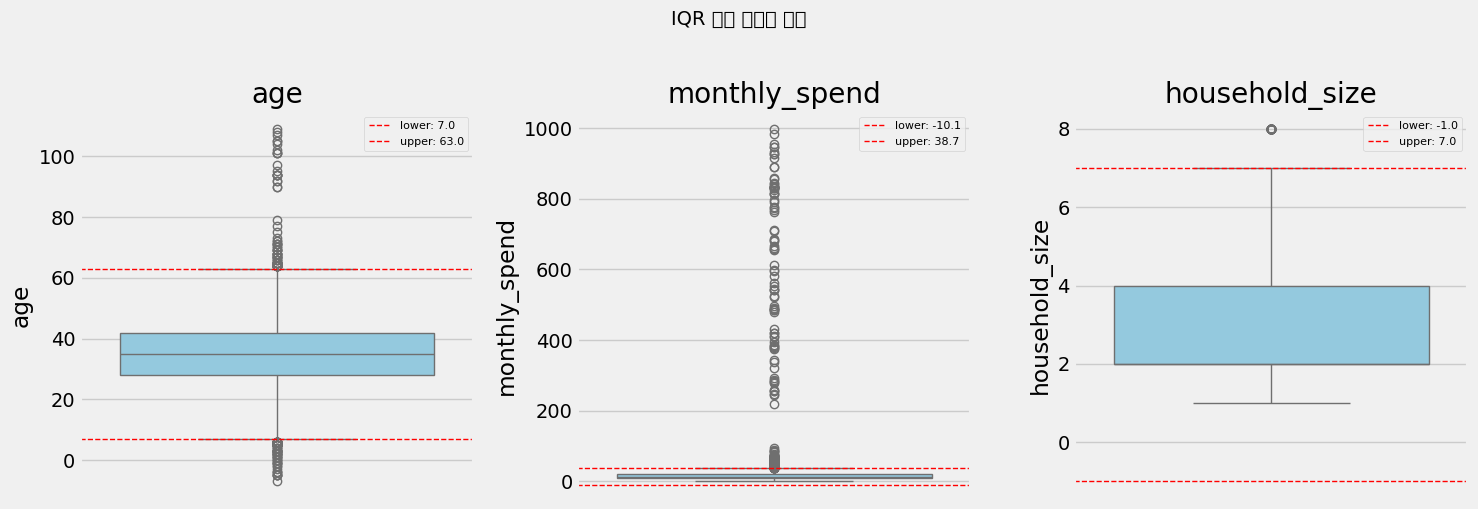

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = train.select_dtypes(include=['number']).columns

fig, axes = plt.subplots(1, len(num_cols), figsize=(5 * len(num_cols), 5))
if len(num_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, num_cols):
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    sns.boxplot(y=train[col], ax=ax, color='skyblue')
    ax.axhline(lower, color='red', linestyle='--', linewidth=1, label=f'lower: {lower:.1f}')
    ax.axhline(upper, color='red', linestyle='--', linewidth=1, label=f'upper: {upper:.1f}')
    ax.set_title(f'{col}')
    ax.legend(fontsize=8)

plt.suptitle('IQR 기반 이상치 탐지', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### data encoding

In [22]:
from sklearn.preprocessing import OneHotEncoder

In [23]:
train.columns

Index(['age', 'gender', 'subscription_plan', 'subscription_start_date',
       'monthly_spend', 'primary_device', 'household_size'],
      dtype='object')

In [24]:
# 범주형(문자열) 데이터 컬럼들을 리스트로 지정.
enc_cols = ['gender', 'subscription_plan','subscription_start_date','primary_device']
# 전체 컬럼에서 범주형 컬럼을 제외한 '나머지 컬럼'들을 추출.
normal_cols = list(set(train.columns) - set(enc_cols))
normal_cols

['household_size', 'monthly_spend', 'age']

In [25]:
# 1. 결과의 재현성을 위해 랜덤 시드(Seed)를 초기화
reset_seeds()

# 2. 인코딩 전 원본 train과 test 데이터의 크기(행, 열 개수)를 출력하여 확인
print(f'before: {train.shape} / {test.shape}')

# 3. OneHotEncoder 객체를 생성 (범주형 데이터를 0과 1로 변환하는 도구)
enc = OneHotEncoder()

# [ train 데이터 변환 과정 ]

# 4. train 데이터의 범주형 컬럼들(enc_cols)을 학습(fit)하고 변환(transform).
# .toarray(): 희소 행렬을 일반 배열 형태로 변환
# columns=...: 새롭게 만들어진 컬럼 이름(예: country_Korea, gender_Female 등)을 부여
tmp_tr = pd.DataFrame(
    enc.fit_transform(train[enc_cols]).toarray(),
    columns = enc.get_feature_names_out()
)

# 5. 기존의 수치형 데이터(normal_cols)와 새로 만든 인코딩 데이터(tmp_tr)를 가로(axis=1)로 합침
# .reset_index(drop=True): 인덱스 번호를 초기화하여 두 데이터가 어긋나지 않게 맞춤
enc_tr = pd.concat(
    [train[normal_cols].reset_index(drop=True), tmp_tr.reset_index(drop=True)]
    , axis=1
)

# [ TEST 데이터 변환 과정 ]

# 6. test 데이터는 새로 학습하지 않고, 반드시 train에서 학습된 기준(enc) 그대로 변환(transform)만 수행.
tmp_te = pd.DataFrame(
    enc.transform(test[enc_cols]).toarray(),
    columns = enc.get_feature_names_out()
)

# 7. test 데이터의 수치형 데이터와 인코딩 데이터를 합침
enc_te = pd.concat(
    [test[normal_cols].reset_index(drop=True), tmp_te.reset_index(drop=True)]
    , axis=1
)

# 8. 인코딩 후 늘어난 컬럼 수를 포함한 최종 데이터 크기를 확인
print(f'after: {enc_tr.shape} / {enc_te.shape}')

# 9. 변환이 완료된 train 데이터의 상단 5행을 출력하여 결과를 확인
enc_tr.head()

before: (8240, 7) / (2060, 7)
after: (8240, 1113) / (2060, 1113)


,household_size,monthly_spend,age,gender_Female,gender_Male,gender_Other,gender_Prefer not to say,subscription_plan_Basic,subscription_plan_Premium,subscription_plan_Premium+,...,subscription_start_date_2025-07-29,subscription_start_date_2025-07-30,subscription_start_date_2025-07-31,subscription_start_date_2025-08-01,primary_device_Desktop,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet
0,1.0,41.40,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,7.06,37.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,3.0,5.11,39.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,3.0,16.79,71.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,13.21,12.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


## Training

In [26]:
enc_tr.isnull().sum().sum(), enc_te.isnull().sum().sum()

(np.int64(0), np.int64(0))

In [27]:
enc_tr.shape, enc_te.shape

((8240, 1113), (2060, 1113))

In [28]:
from sklearn.tree import DecisionTreeClassifier

In [29]:
reset_seeds() # 랜덤 고정

model = DecisionTreeClassifier()  # 모델 생성

print(f'{enc_tr.shape} / {y_tr.shape}')
model.fit(enc_tr, y_tr)

(8240, 1113) / (8240,)


DecisionTreeClassifier()

## Evaluation

In [30]:
reset_seeds()

score_tr = model.score(enc_tr, y_tr) # 학습용 데이터셋으로 평가
score_te = model.score(enc_te, y_te) # 평가용 데이터셋으로 평가

score_tr, score_te

(1.0, 0.7810679611650485)

In [31]:
from sklearn.metrics import (
    roc_curve, auc,
    confusion_matrix, classification_report,
    accuracy_score, precision_score, recall_score, f1_score
)
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 각 유저가 이탈(Yes)할 확률을 계산
# [:, 1]은 두 번째 컬럼인 '이탈할 확률'만 가져오겠다는 뜻
y_prob = model.predict_proba(enc_te)[:, 1]

# 2. 확률이 0.5보다 크면 이탈(1), 작으면 유지(0)로 분류
y_pred = (y_prob > 0.5).astype(int)

# pos_label='Yes'를 추가하여 'Yes'가 True임을 명시
fpr, tpr, thresholds = roc_curve(y_te, y_prob, pos_label=1)
auc_te = auc(fpr, tpr)
print(f'model AUC: {auc_te}')

model AUC: 0.541025641025641


In [32]:
# 테스트 데이터(enc_te)에 예측 결과를 붙여서 확인
result_Netflix = enc_te.copy()
result_Netflix['churn_probability'] = y_prob  # 이탈 확률
result_Netflix['predicted_churn'] = y_pred    # 이탈 여부 예측 (0 또는 1)

# 모델이 '이탈(1)'로 예측한 회원들만 필터링
predicted_churners = result_Netflix[result_Netflix['predicted_churn'] == 1]

print(f"전체 테스트 회원 수: {len(result_Netflix)}명")
print(f"모델이 예측한 이탈 회원 수: {len(predicted_churners)}명")
predicted_churners.head()

전체 테스트 회원 수: 2060명
모델이 예측한 이탈 회원 수: 268명


,household_size,monthly_spend,age,gender_Female,gender_Male,gender_Other,gender_Prefer not to say,subscription_plan_Basic,subscription_plan_Premium,subscription_plan_Premium+,...,subscription_start_date_2025-07-31,subscription_start_date_2025-08-01,primary_device_Desktop,primary_device_Gaming Console,primary_device_Laptop,primary_device_Mobile,primary_device_Smart TV,primary_device_Tablet,churn_probability,predicted_churn
1,2.0,2.96,29.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1
5,4.0,8.65,31.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1
9,2.0,35.87,34.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
33,3.0,17.62,56.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
46,5.0,13.03,42.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1


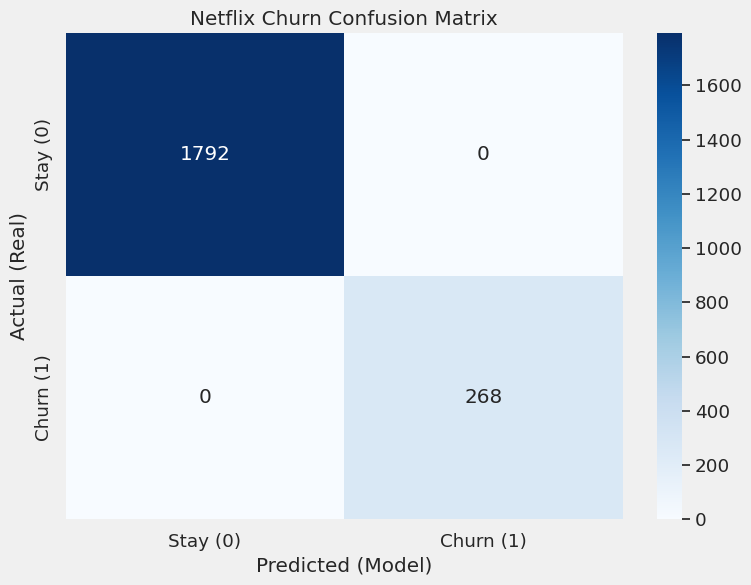

         혼동 행렬(Confusion Matrix) 해석
✅ TN (True Negative)  :  1,792명
   → 유지인데, 모델도 유지로 정확히 예측

❌ FP (False Positive) :      0명
   → 유지인데, 모델이 이탈로 잘못 예측

❌ FN (False Negative) :      0명
   → 실제 이탈인데, 모델이 유지로 잘못 예측

✅ TP (True Positive)  :    268명
   → 실제 이탈인데, 모델도 이탈으로 정확히 예측

📊 파생 지표 요약
  Accuracy  (전체 정확도)     : 1.0000  → 전체 중 맞춘 비율
  Precision (정밀도)          : 1.0000  → Churn 예측 중 실제 Churn 비율
  Recall    (재현율)          : 1.0000  → 실제 Churn 중 맞춘 비율
  F1 Score  (정밀도+재현율)   : 1.0000  → Precision과 Recall의 조화 평균


In [33]:
# 1. 혼동 행렬 데이터 생성
# y_prob: 실제 정답(0, 1), y_pred: 모델의 예측값(0, 1)
cm = confusion_matrix(y_prob, y_pred)

# 2. 그래프 크기 및 스타일 설정
plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2) # 글자 크기 조절

# 3. 히트맵(Heatmap) 그리기
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay (0)', 'Churn (1)'],
            yticklabels=['Stay (0)', 'Churn (1)'])

# 4. 라벨 및 타이틀 추가
plt.xlabel('Predicted (Model)')
plt.ylabel('Actual (Real)')
plt.title('Netflix Churn Confusion Matrix')
plt.show()

# 5. 혼동 행렬 각 값 추출
tn, fp, fn, tp = cm.ravel()

# 6. 각 숫자의 의미 출력
print("=" * 45)
print("         혼동 행렬(Confusion Matrix) 해석")
print("=" * 45)
print(f"✅ TN (True Negative)  : {tn:>6,}명")
print(f"   → 유지인데, 모델도 유지로 정확히 예측")
print()
print(f"❌ FP (False Positive) : {fp:>6,}명")
print(f"   → 유지인데, 모델이 이탈로 잘못 예측")
print()
print(f"❌ FN (False Negative) : {fn:>6,}명")
print(f"   → 실제 이탈인데, 모델이 유지로 잘못 예측")
print()
print(f"✅ TP (True Positive)  : {tp:>6,}명")
print(f"   → 실제 이탈인데, 모델도 이탈으로 정확히 예측")
print("=" * 45)

# 7. 파생 지표 출력
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print(f"\n📊 파생 지표 요약")
print("=" * 45)
print(f"  Accuracy  (전체 정확도)     : {accuracy:.4f}  → 전체 중 맞춘 비율")
print(f"  Precision (정밀도)          : {precision:.4f}  → Churn 예측 중 실제 Churn 비율")
print(f"  Recall    (재현율)          : {recall:.4f}  → 실제 Churn 중 맞춘 비율")
print(f"  F1 Score  (정밀도+재현율)   : {f1:.4f}  → Precision과 Recall의 조화 평균")
print("=" * 45)

In [34]:
# column별 중요도
df_feature_importances = pd.DataFrame(
    model.feature_importances_,
    index=enc_tr.columns,
    columns=['importance']
).sort_values(by='importance', ascending=False).reset_index()

# 중요도를 % 형식으로 추가
df_feature_importances['importance_%'] = (
    df_feature_importances['importance'] * 100
).round(2).astype(str) + '%'

df_feature_importances[['index', 'importance_%']]

,index,importance_%
0,monthly_spend,7.03%
1,age,5.43%
2,household_size,3.3%
3,gender_Male,2.16%
4,gender_Female,2.01%
...,...,...
1108,subscription_start_date_2024-07-21,0.0%
1109,subscription_start_date_2024-07-25,0.0%
1110,subscription_start_date_2024-07-27,0.0%
1111,subscription_start_date_2024-07-29,0.0%


In [35]:
args.results.append(
    {
        'model': 'modelV0',
        'score_tr': score_tr,
        'score_te': score_te,
        'auc_te': auc_te,
        'len_features': X_tr.shape[1],
        'feaute_importances': list(df_feature_importances['index'].values[:X_tr.shape[1]]),
        'create_dt': '0327'
    }
)

args.results

[{'model': 'modelV0',
  'score_tr': 1.0,
  'score_te': 0.7810679611650485,
  'auc_te': np.float64(0.541025641025641),
  'len_features': 15,
  'feaute_importances': ['monthly_spend',
   'age',
   'household_size',
   'gender_Male',
   'gender_Female',
   'subscription_plan_Premium',
   'primary_device_Laptop',
   'primary_device_Tablet',
   'primary_device_Desktop',
   'primary_device_Mobile',
   'subscription_plan_Standard',
   'primary_device_Gaming Console',
   'subscription_plan_Basic',
   'primary_device_Smart TV',
   'subscription_plan_Premium+'],
  'create_dt': '0327'}]

# Submission

In [36]:
Netflix_results = pd.DataFrame(args.results).sort_values(by=['auc_te'], ascending=False)
Netflix_results

,model,score_tr,score_te,auc_te,len_features,feaute_importances,create_dt
0,modelV0,1.0,0.781068,0.541026,15,"[monthly_spend, age, household_size, gender_Ma...",0327


In [37]:
# 파일 저장
X_tr.to_csv(args.train_csv, index=False)
X_te.to_csv(args.test_csv, index=False)

# Submission 양식 생성
submission_Netflix = X_te[['user_id']].copy()
submission_Netflix['is_churned'] = 0  # 임시 정답값
submission_Netflix.to_csv(args.default_submission_csv, index=False)

# Save Results

In [38]:
# 1. 모델로 예측
submission_Netflix['is_churned'] = model.predict(enc_te)

# 2. 최종 파일 저장
submission_Netflix.to_csv(args.default_submission_csv, index=False)

print(f"저장 완료: {args.default_submission_csv}")

저장 완료: /content/drive/MyDrive/project/data/Netflix_submission.csv


In [39]:
import json

# 1. 모델 평가 지표 계산
accuracy = round(accuracy_score(y_te, y_pred), 4)

results = {
    "accuracy":  accuracy,
    "loss":      round(1 - accuracy, 4),  # 오차율 추가
    "precision": round(precision_score(y_te, y_pred), 4),
    "recall":    round(recall_score(y_te, y_pred), 4),
    "f1_score":  round(f1_score(y_te, y_pred), 4)
}

# 2. JSON 파일로 저장
with open(args.save_results, 'w') as file:
    json.dump(results, file, indent=4)

print(f"저장 완료: {args.save_results}")
print(json.dumps(results, indent=4))

저장 완료: /content/drive/MyDrive/project/data/Netflix_results.json
{
    "accuracy": 0.7811,
    "loss": 0.2189,
    "precision": 0.2276,
    "recall": 0.2,
    "f1_score": 0.2129
}


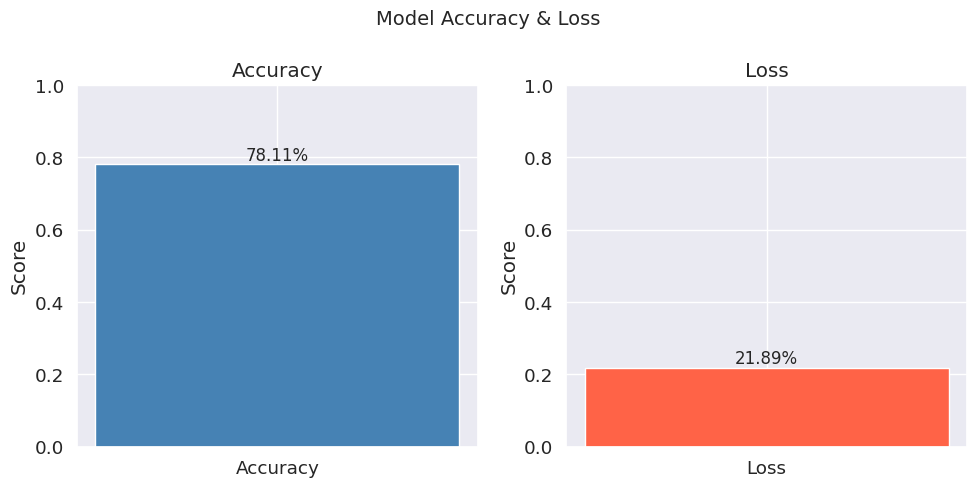

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Accuracy 그래프
axes[0].bar(['Accuracy'], [results['accuracy']], color='steelblue', width=0.4)
axes[0].set_ylim(0, 1)
axes[0].set_title('Accuracy')
axes[0].set_ylabel('Score')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{results['accuracy']*100:.2f}%", ha='center', fontsize=12)

# Loss 그래프
axes[1].bar(['Loss'], [results['loss']], color='tomato', width=0.4)
axes[1].set_ylim(0, 1)
axes[1].set_title('Loss')
axes[1].set_ylabel('Score')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{results['loss']*100:.2f}%", ha='center', fontsize=12)

plt.suptitle('Model Accuracy & Loss', fontsize=14)
plt.tight_layout()
plt.show()